# Week 2 - Day 9

# Correlation Analysis & Hypothesis Testing

## Objective

The purpose of this notebook is to perform statistical analysis on the Marketing Campaign dataset.

Tasks:

- Correlation Analysis
- Correlation Heatmap
- T-Test
- Chi-Square Test
- Feature Ranking

Dataset:
Marketing Campaign Dataset

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

# Dataset Loading

The dataset is loaded using Pandas for further statistical analysis.

In [3]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

print("Shape:", df.shape)

df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Dataset Overview

Understanding the structure of the dataset before statistical analysis.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


# Task 1: Correlation Analysis

Correlation measures the strength and direction of the relationship between numerical variables.

Range:

- +1 = Strong Positive Correlation
- 0 = No Correlation
- -1 = Strong Negative Correlation

In [6]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,5,0,0,0,0,0,0,3,11,0


In [7]:
corr_matrix = numeric_df.corr()

corr_matrix

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,1.000000,0.000028,0.013095,0.002406,-0.002580,-0.046524,-0.022878,0.004600,-0.004437,-0.024475,...,-0.007446,-0.036040,-0.025387,-0.007517,-0.021614,-0.015061,0.033883,NaN,NaN,-0.021968
Year_Birth,0.000028,1.000000,-0.161791,0.230176,-0.352111,-0.019871,-0.157773,-0.017917,-0.030872,-0.041625,...,0.121139,0.061774,-0.060510,0.007123,-0.005930,-0.006539,-0.030128,NaN,NaN,0.021325
Income,0.013095,-0.161791,1.000000,-0.428669,0.019133,-0.003970,0.578650,0.430842,0.584633,0.438871,...,-0.553088,-0.016174,0.184400,0.335943,0.276820,0.087545,-0.027225,NaN,NaN,0.133047
Kidhome,0.002406,0.230176,-0.428669,1.000000,-0.036133,0.008827,-0.496297,-0.372581,-0.437129,-0.387644,...,0.447846,0.014674,-0.161600,-0.205634,-0.172339,-0.081716,0.040207,NaN,NaN,-0.080008
Teenhome,-0.002580,-0.352111,0.019133,-0.036133,1.000000,0.016198,0.004846,-0.176764,-0.261160,-0.204187,...,0.134884,-0.042677,0.038886,-0.191050,-0.140090,-0.015605,0.003138,NaN,NaN,-0.154446
Recency,-0.046524,-0.019871,-0.003970,0.008827,0.016198,1.000000,0.016064,-0.004306,0.023056,0.001079,...,-0.021445,-0.032991,0.018826,0.000129,-0.019283,-0.001781,0.013231,NaN,NaN,-0.198437
MntWines,-0.022878,-0.157773,0.578650,-0.496297,0.004846,0.016064,1.000000,0.389637,0.562667,0.399753,...,-0.320653,0.062202,0.373286,0.472613,0.354133,0.205907,-0.039007,NaN,NaN,0.247254
MntFruits,0.004600,-0.017917,0.430842,-0.372581,-0.176764,-0.004306,0.389637,1.000000,0.543105,0.594804,...,-0.418383,0.014727,0.010152,0.215833,0.194748,-0.009773,-0.005166,NaN,NaN,0.125289
MntMeatProducts,-0.004437,-0.030872,0.584633,-0.437129,-0.261160,0.023056,0.562667,0.543105,1.000000,0.568402,...,-0.539470,0.018272,0.102912,0.373769,0.309761,0.043033,-0.023483,NaN,NaN,0.236335
MntFishProducts,-0.024475,-0.041625,0.438871,-0.387644,-0.204187,0.001079,0.399753,0.594804,0.568402,1.000000,...,-0.446003,0.000357,0.016843,0.199578,0.260762,0.002577,-0.020953,NaN,NaN,0.111331


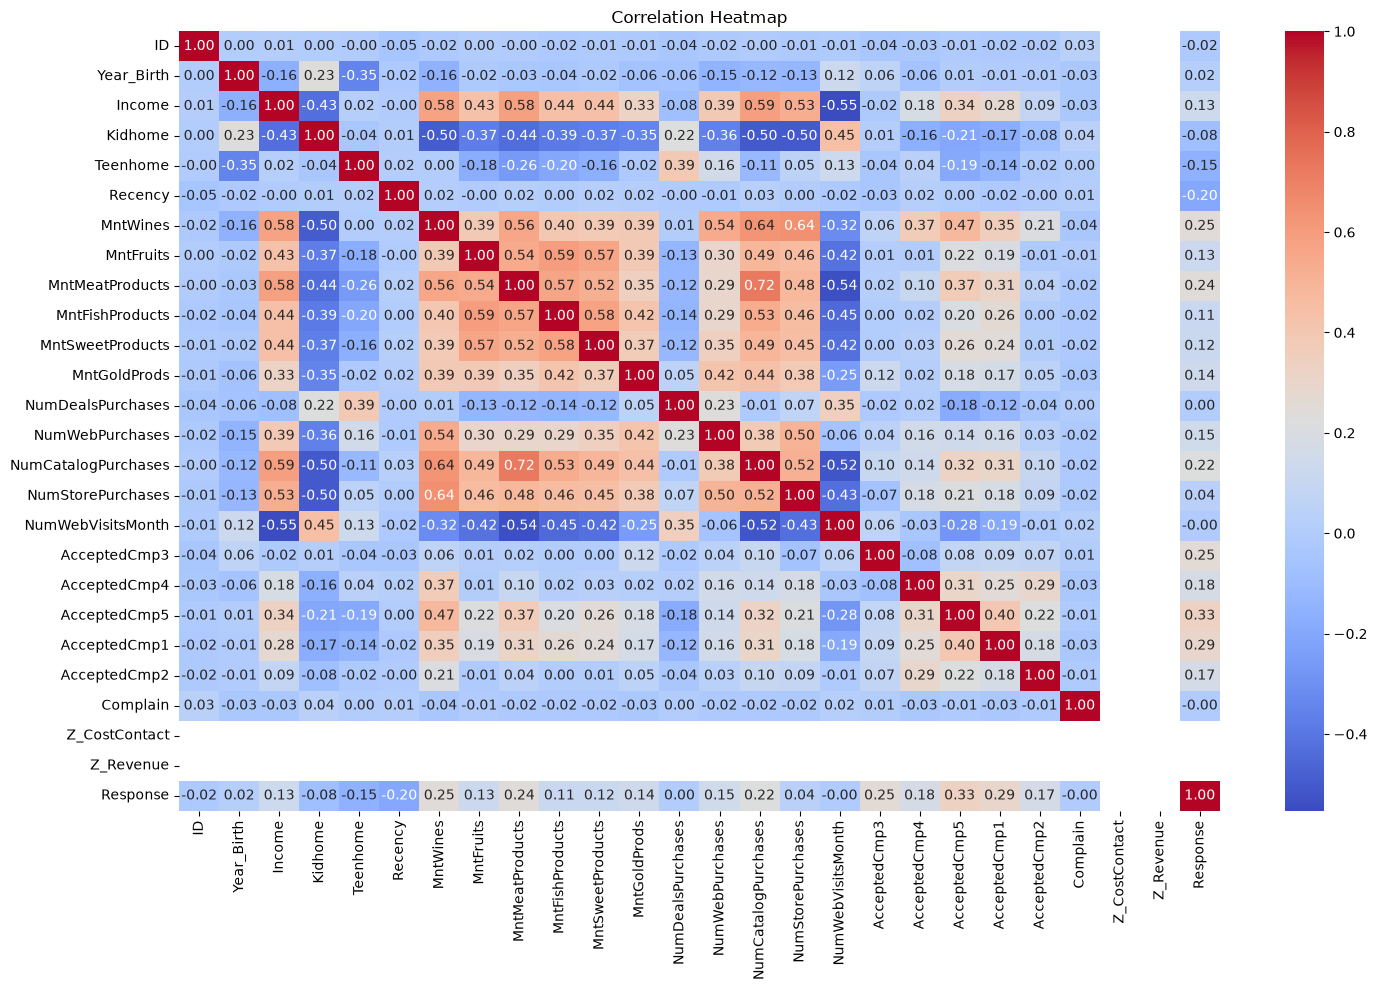

In [8]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("outputs/correlation_heatmap.png")

plt.show()

## Correlation Findings

The heatmap helps identify relationships among numerical variables.

Strong correlations may indicate important predictors for machine learning models.

In [9]:
target_corr = corr_matrix["Response"]

target_corr.sort_values(ascending=False)

Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
NumWebPurchases        0.148730
MntGoldProds           0.139850
Income                 0.133047
MntFruits              0.125289
MntSweetProducts       0.117372
MntFishProducts        0.111331
NumStorePurchases      0.039363
Year_Birth             0.021325
NumDealsPurchases      0.002238
Complain              -0.001707
NumWebVisitsMonth     -0.003987
ID                    -0.021968
Kidhome               -0.080008
Teenhome              -0.154446
Recency               -0.198437
Z_CostContact               NaN
Z_Revenue                   NaN
Name: Response, dtype: float64

In [10]:
top_features = (
    target_corr
    .drop("Response")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_features

AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
Recency                0.198437
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
Teenhome               0.154446
Name: Response, dtype: float64

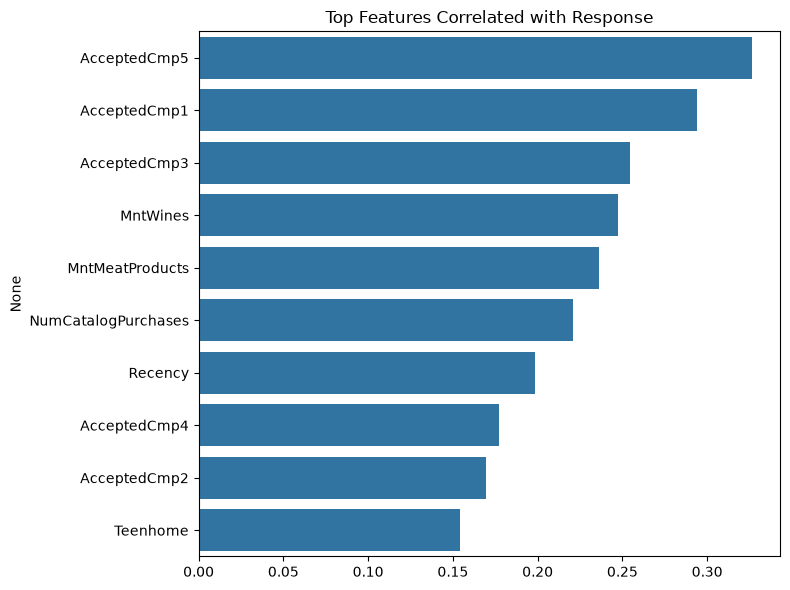

In [11]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Features Correlated with Response")

plt.tight_layout()

plt.savefig("outputs/top_correlated_features.png")

plt.show()

# Task 2: T-Test

T-Test compares the means of two groups.

Null Hypothesis (H0):
There is no significant difference.

Alternative Hypothesis (H1):
There is a significant difference.

Decision:

- p < 0.05 → Reject H0
- p ≥ 0.05 → Fail to Reject H0

In [12]:
group1 = df[df["Response"] == 1]["Income"].dropna()

group2 = df[df["Response"] == 0]["Income"].dropna()

t_stat, p_value = ttest_ind(
    group1,
    group2
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 6.316420548976486
P Value: 3.2255685843409974e-10


In [13]:
group1 = df[df["Response"] == 1]["MntWines"]

group2 = df[df["Response"] == 0]["MntWines"]

t_stat, p_value = ttest_ind(
    group1,
    group2
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 12.071816351437846
P Value: 1.4925307948444043e-32


In [14]:
group1 = df[df["Response"] == 1]["NumWebPurchases"]

group2 = df[df["Response"] == 0]["NumWebPurchases"]

t_stat, p_value = ttest_ind(
    group1,
    group2
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 7.115161040070559
P Value: 1.4985878994096545e-12


In [15]:
results = []

for feature in [
    "Income",
    "MntWines",
    "NumWebPurchases"
]:

    g1 = df[df["Response"] == 1][feature].dropna()
    g2 = df[df["Response"] == 0][feature].dropna()

    t,p = ttest_ind(g1,g2)

    results.append([feature,t,p])

ttest_df = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "T Statistic",
        "P Value"
    ]
)

ttest_df

,Feature,T Statistic,P Value
0,Income,6.316421,3.225569e-10
1,MntWines,12.071816,1.492531e-32
2,NumWebPurchases,7.115161,1.498588e-12


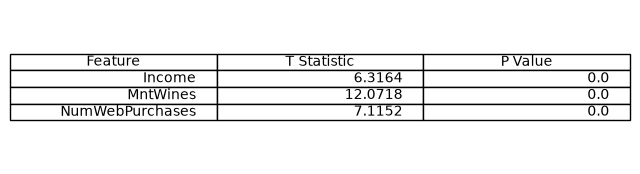

In [16]:
plt.figure(figsize=(8,2))

plt.axis("off")

plt.table(
    cellText=ttest_df.round(4).values,
    colLabels=ttest_df.columns,
    loc="center"
)

plt.savefig("outputs/ttest_results.png")

plt.show()

# Task 3: Chi-Square Test

Chi-Square Test determines whether two categorical variables are related.

In [17]:
table = pd.crosstab(
    df["Education"],
    df["Response"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi Square:", chi2)
print("P Value:", p)

Chi Square: 23.0760975769431
P Value: 0.00012226975294505314


In [18]:
table = pd.crosstab(
    df["Marital_Status"],
    df["Response"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi Square:", chi2)
print("P Value:", p)

Chi Square: 54.241636705551365
P Value: 2.1067470540907e-09


In [19]:
chi_results = []

for feature in [
    "Education",
    "Marital_Status"
]:

    table = pd.crosstab(
        df[feature],
        df["Response"]
    )

    chi2,p,dof,expected = chi2_contingency(table)

    chi_results.append([
        feature,
        chi2,
        p
    ])

chi_df = pd.DataFrame(
    chi_results,
    columns=[
        "Feature",
        "Chi Square",
        "P Value"
    ]
)

chi_df

,Feature,Chi Square,P Value
0,Education,23.076098,1.222698e-04
1,Marital_Status,54.241637,2.106747e-09


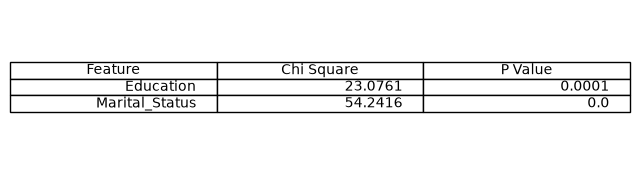

In [20]:
plt.figure(figsize=(8,2))

plt.axis("off")

plt.table(
    cellText=chi_df.round(4).values,
    colLabels=chi_df.columns,
    loc="center"
)

plt.savefig("outputs/chi_square_results.png")

plt.show()

# Task 4: Feature Importance Ranking

Features are ranked according to their correlation with the target variable.

In [21]:
feature_rank = (
    corr_matrix["Response"]
    .drop("Response")
    .abs()
    .sort_values(ascending=False)
)

feature_rank.head(10)

AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
Recency                0.198437
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
Teenhome               0.154446
Name: Response, dtype: float64

In [22]:
top5 = feature_rank.head(5)

top5

AcceptedCmp5       0.326634
AcceptedCmp1       0.293982
AcceptedCmp3       0.254258
MntWines           0.247254
MntMeatProducts    0.236335
Name: Response, dtype: float64

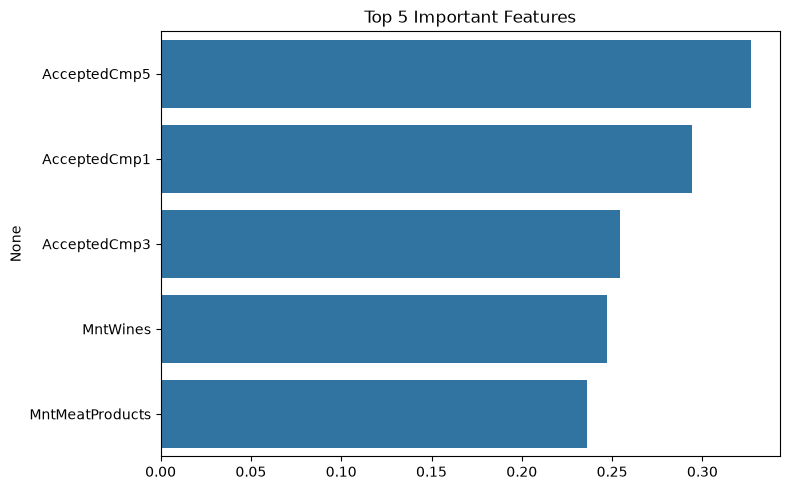

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top5.values,
    y=top5.index
)

plt.title("Top 5 Important Features")

plt.tight_layout()

plt.savefig("outputs/feature_importance.png")

plt.show()

# Conclusion

## Correlation Analysis

The strongest relationships between variables were identified using a correlation matrix and heatmap.

## T-Test Analysis

Statistical tests showed whether significant differences exist between customer groups.

## Chi-Square Analysis

Categorical variables were tested to determine their relationship with customer responses.

## Feature Ranking

Important features were ranked based on statistical evidence.

## Outcome

The findings provide a strong foundation for machine learning model development in Week 3.